# Task 4 — Layer 5: Explanation Generation

| Layer | Role | Notebook |
|-------|------|----------|
| Layer 1 | Ontology → Knowledge Graph | Task 1 (Davide) |
| Layer 2 | Neural link predictions | Task 2 (Aya) |
| Layer 3 | Symbolic filter | Task 3 (Fabio) |
| Layer 4 | Neuro-symbolic ranking | Task 3 (Fabio) |
| **Layer 5** | **Explanation generation** | **This notebook** |

For each recommendation produced by Task 3, this notebook:
1. Reconstructs the **exact path** in the ontology connecting the Java topic to the game element
2. Generates a **human-readable explanation** using independent modular blocks
3. Exports a structured CSV ready to be shown to teachers

**Required input files (upload to Colab):**
- `task3_topk_per_topic.csv` — output of Task 3
- `edgesNew.csv` — ontology edges from Task 1
- `nodesNew.csv` — ontology nodes from Task 1

## 1. Imports

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## 2. Load Inputs

In [4]:
df_topk  = pd.read_csv('task3/task3_topk_per_topic.csv')
df_edges = pd.read_csv('edges.csv')
df_nodes = pd.read_csv('nodes.csv')

# Strip whitespace from all ID columns
for col in ['source', 'target']:
    df_topk[col]  = df_topk[col].astype(str).str.strip()
    df_edges[col] = df_edges[col].astype(str).str.strip()
df_nodes['label'] = df_nodes['label'].astype(str).str.strip()

print(f'Recommendations : {len(df_topk)} rows')
print(f'Ontology edges  : {len(df_edges)} rows')
print(f'Ontology nodes  : {len(df_nodes)} rows')
print()

# Sanity check: verify edges match task3 sources
task3_sources = set(df_topk['source'].unique())
edge_nodes    = set(df_edges['source'].unique()) | set(df_edges['target'].unique())
overlap       = task3_sources & edge_nodes
print(f'Task3 sources found in edges.csv: {len(overlap)} / {len(task3_sources)}')
if len(overlap) < len(task3_sources):
    missing = task3_sources - edge_nodes
    print(f'  WARNING — not found: {missing}')
else:
    print('  OK — all sources present.')
print()
df_topk.head()

Recommendations : 54 rows
Ontology edges  : 653 rows
Ontology nodes  : 480 rows

Task3 sources found in edges.csv: 15 / 15
  OK — all sources present.



,source,target,probability_mean,probability_std,known_positive,source_type,target_type,symbolic_confidence,neurosymbolic_score
0,Arithmetic_operations,Stash,0.616297,0.192879,True,NamedIndividual,NamedIndividual,1.0,0.884889
1,Task_about_Java_Basics,Level_Up,0.614525,0.206983,True,NamedIndividual,NamedIndividual,1.0,0.884358
2,Task_about_Java_Basics,BLockGame,0.614416,0.207101,True,NamedIndividual,NamedIndividual,1.0,0.884325
3,Task_about_Java_Basics,Stash,0.614416,0.207101,True,NamedIndividual,NamedIndividual,1.0,0.884325
4,Buil-in_Data_Types,Level_Up,0.589158,0.150940,True,NamedIndividual,NamedIndividual,1.0,0.876747


## 3. Build the Ontology Graph

We rebuild the same graph used in Task 3 so we can retrieve the actual path
between each Java topic and its recommended game element.

In [5]:
label_set = set(df_nodes['label'])

G = nx.DiGraph()
for _, row in df_nodes.iterrows():
    G.add_node(row['label'], primary_type=str(row.get('primary_type', 'unknown')))

for _, row in df_edges.iterrows():
    src, tgt, rel = row['source'], row['target'], str(row['relation']).strip()
    if src in label_set and tgt in label_set:
        G.add_edge(src, tgt, relation=rel)

G_undir = G.to_undirected()

print(f'Graph — nodes: {G.number_of_nodes():,} | edges: {G.number_of_edges():,}')
print()
print('Relation types in the ontology:')
print(df_edges['relation'].value_counts().to_string())

Graph — nodes: 459 | edges: 607

Relation types in the ontology:
relation
domain                       172
range                         89
subClassOf                    73
is_visible_for                54
indexed_by                    53
contains                      47
hasPreResource                37
has_reference                 33
subPropertyOf                 21
containsGameElement           20
consists_of                    9
hasPreLesson                   8
designedWithObjective          4
disjointWith                   4
has_user_account               3
hasGamificationExperience      3
hasObjective                   3
member_of                      3
usergroup_of                   2
imports                        2
equivalentClass                2
isComposedOf                   2
index                          2
versionIRI                     1
has_usergroup                  1
hasTargetAudience              1
offersCourse                   1
teaches                        1
wo

## 4. Path Reconstruction

For each `(source, target)` pair, we find the shortest path in the undirected ontology graph
and extract the **relation type of each edge** along the path.

This gives us a chain like:
```
Arithmetic_operations --hasPreResource--> Task_about_Java_Basics --containsGameElement--> BLockGame
```
which is a concrete, interpretable justification for the recommendation.

In [6]:
def get_path(source, target):
    """Returns shortest path as a list of node labels, or [] if none."""
    if G.has_edge(source, target) or G.has_edge(target, source):
        return [source, target]
    try:
        return nx.shortest_path(G_undir, source=source, target=target)
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return []


def get_edge_relations(path):
    """Returns list of relation labels along the path edges."""
    rels = []
    for i in range(len(path) - 1):
        a, b = path[i], path[i+1]
        if G.has_edge(a, b):
            rels.append(G[a][b].get('relation', '?'))
        elif G.has_edge(b, a):
            rels.append(G[b][a].get('relation', '?') + '(rev)')
        else:
            rels.append('?')
    return rels


def format_path_with_relations(path):
    """Formats path as: NodeA --relation--> NodeB --relation--> NodeC"""
    if not path:
        return 'no path found'
    rels = get_edge_relations(path)
    result = path[0]
    for node, rel in zip(path[1:], rels):
        result += f' --{rel}--> {node}'
    return result


# --- Test on real examples from the dataset ---
print('=== Path reconstruction test ===')
test_pairs = [
    ('Variables',              'Level_Up'),   # direct, known
    ('Arithmetic_operations',  'BLockGame'),  # indirect dist=2, novel
    ('Variables',              'BLockGame'),  # indirect dist=?, novel
    ('Loops',                  'Stash'),      # indirect, novel
]
for src, tgt in test_pairs:
    path = get_path(src, tgt)
    print(f'\n{src} → {tgt}')
    print(f'  Distance : {len(path)-1 if path else "no path"}')
    print(f'  Full path: {format_path_with_relations(path)}')

=== Path reconstruction test ===

Variables → Level_Up
  Distance : 1
  Full path: Variables --containsGameElement--> Level_Up

Arithmetic_operations → BLockGame
  Distance : 2
  Full path: Arithmetic_operations --hasPreResource--> Task_about_Java_Basics --containsGameElement--> BLockGame

Variables → BLockGame
  Distance : 3
  Full path: Variables --contains(rev)--> Java_Basics --contains--> Control_Statements --containsGameElement--> BLockGame

Loops → Stash
  Distance : 2
  Full path: Loops --hasPreResource--> Control_Statements --containsGameElement--> Stash


## 5. Game Element Descriptions

A lookup table that maps each game element to a short description of what it is
and what pedagogical purpose it serves. This is used in Block 4 of the explanation.

In [7]:
GAME_ELEMENT_DESCRIPTIONS = {
    'BLockGame'                    : 'a block-based coding game that reinforces logical reasoning and sequential thinking',
    'Level_Up'                     : 'a leveling system that rewards progressive mastery of the topic',
    'Stash'                        : 'a collection mechanic that incentivizes completing exercises and accumulating resources',
    'Tiny_stash'                   : 'a lightweight version of the stash mechanic, suitable for shorter activities',
    'Motrain'                      : 'a motivation and reward platform that tracks student engagement over time',
    'bonusPoints'                  : 'a bonus points system that rewards extra effort and participation',
    'Availability_Block_Game_by_level': 'a gated game element that becomes available as students advance through levels',
}

def get_element_description(target):
    return GAME_ELEMENT_DESCRIPTIONS.get(target, 'a gamification element designed to increase student engagement')

print('Game element descriptions loaded.')
for k, v in GAME_ELEMENT_DESCRIPTIONS.items():
    print(f'  {k}: {v[:60]}...')

Game element descriptions loaded.
  BLockGame: a block-based coding game that reinforces logical reasoning ...
  Level_Up: a leveling system that rewards progressive mastery of the to...
  Stash: a collection mechanic that incentivizes completing exercises...
  Tiny_stash: a lightweight version of the stash mechanic, suitable for sh...
  Motrain: a motivation and reward platform that tracks student engagem...
  bonusPoints: a bonus points system that rewards extra effort and particip...
  Availability_Block_Game_by_level: a gated game element that becomes available as students adva...


## 6. Explanation Blocks

The explanation is built from **4 independent blocks**. Each block is a separate function
that answers one specific question. They are joined into a final paragraph.

To add a new dimension in the future (e.g. teacher experience level), just write
a new block function and add it to `generate_explanation()` — nothing else changes.

```
Block 1 — Strength      : How confident is the recommendation?
Block 2 — Ontology      : What is the ontological justification?
Block 3 — Path          : What is the exact chain of concepts?
Block 4 — Game element  : What does this element do pedagogically?
```

In [8]:
def block_strength(source, target, score, known_positive):
    """Block 1 — Recommendation strength and validation status."""
    status = 'validated' if known_positive else 'novel'
    if score >= 0.80:
        return (f"{target} is strongly recommended for {source} "
                f"(neuro-symbolic score: {score:.3f} — High confidence, {status} recommendation).")
    elif score >= 0.45:
        return (f"{target} is recommended for {source} "
                f"(neuro-symbolic score: {score:.3f} — Moderate confidence, {status} recommendation).")
    else:
        return (f"{target} is proposed as an exploratory suggestion for {source} "
                f"(neuro-symbolic score: {score:.3f} — Weak confidence, {status} recommendation).")


def block_ontology(conf, path, rels):
    """Block 2 — Ontological support based on path type and confidence."""
    dist = len(path) - 1 if path else 0
    if conf == 1.0:
        main_rel = rels[0] if rels else 'containsGameElement'
        return (f"The ontology directly validates this recommendation via "
                f"a '{main_rel}' relation (ontological confidence: 1.0).")
    elif conf >= 0.4:
        return (f"The ontology indirectly supports this recommendation through "
                f"{dist-1} intermediate concept(s) in the knowledge graph "
                f"(confidence: {conf:.2f}).")
    elif conf > 0:
        return (f"The ontological connection is weak, passing through "
                f"{dist-1} intermediate concept(s) in the knowledge graph "
                f"(confidence: {conf:.2f}).")
    else:
        return "No ontological path was found for this pair."


def block_path(path):
    """Block 3 — The explicit ontological path with relation types."""
    if not path or len(path) < 2:
        return ""
    formatted = format_path_with_relations(path)
    return f"Ontological path: [{formatted}]."


def block_game_element(target):
    """Block 4 — What the game element does pedagogically."""
    desc = get_element_description(target)
    return f"{target} is {desc}."


def generate_explanation(source, target, score, conf, known_positive, path):
    """Joins all 4 blocks into a final paragraph."""
    rels = get_edge_relations(path)
    blocks = [
        block_strength(source, target, score, known_positive),
        block_ontology(conf, path, rels),
        block_path(path),
        block_game_element(target),
    ]
    return ' '.join(b for b in blocks if b)


print('Explanation blocks defined.')

Explanation blocks defined.


### 6.1 Test with Real Examples

In [9]:
# Test on the first row of each confidence level
test_cases = [
    # source, target, score, conf, known_positive
    ('Variables',             'Level_Up',  0.869, 1.000, True),
    ('Arithmetic_operations', 'BLockGame', 0.536, 0.500, False),
    ('Variables',             'BLockGame', 0.403, 0.333, False),
]

for src, tgt, score, conf, known in test_cases:
    path = get_path(src, tgt)
    exp  = generate_explanation(src, tgt, score, conf, known, path)
    print(f'=== {src} → {tgt} (conf={conf}) ===')
    print(exp)
    print()

=== Variables → Level_Up (conf=1.0) ===
Level_Up is strongly recommended for Variables (neuro-symbolic score: 0.869 — High confidence, validated recommendation). The ontology directly validates this recommendation via a 'containsGameElement' relation (ontological confidence: 1.0). Ontological path: [Variables --containsGameElement--> Level_Up]. Level_Up is a leveling system that rewards progressive mastery of the topic.

=== Arithmetic_operations → BLockGame (conf=0.5) ===
BLockGame is recommended for Arithmetic_operations (neuro-symbolic score: 0.536 — Moderate confidence, novel recommendation). The ontology indirectly supports this recommendation through 1 intermediate concept(s) in the knowledge graph (confidence: 0.50). Ontological path: [Arithmetic_operations --hasPreResource--> Task_about_Java_Basics --containsGameElement--> BLockGame]. BLockGame is a block-based coding game that reinforces logical reasoning and sequential thinking.

=== Variables → BLockGame (conf=0.333) ===
BLo

## 7. Generate All Explanations

In [10]:
print('Generating explanations for all recommendations...')

paths_formatted = []
distances       = []
conf_labels     = []
key_relations   = []
explanations    = []

for _, row in df_topk.iterrows():
    src  = row['source']
    tgt  = row['target']
    conf = row['symbolic_confidence']
    score = row['neurosymbolic_score']
    known = row['known_positive']

    path = get_path(src, tgt)
    rels = get_edge_relations(path)
    dist = len(path) - 1 if path else 0

    conf_label = 'High' if conf == 1.0 else ('Moderate' if conf >= 0.4 else 'Weak')
    key_rel    = rels[0] if rels else 'unknown'

    paths_formatted.append(format_path_with_relations(path))
    distances.append(dist)
    conf_labels.append(conf_label)
    key_relations.append(key_rel)
    explanations.append(generate_explanation(src, tgt, score, conf, known, path))

df_out = df_topk.copy()
df_out['confidence_label'] = conf_labels
df_out['path_distance']    = distances
df_out['key_relation']     = key_relations
df_out['ontology_path']    = paths_formatted
df_out['explanation']      = explanations

print(f'Done. {len(df_out)} explanations generated.')

Generating explanations for all recommendations...
Done. 54 explanations generated.


## 8. Results

In [11]:
print('=== Confidence Label Distribution ===')
print(df_out['confidence_label'].value_counts().to_string())
print()
print('=== Path Distance Distribution ===')
print(df_out['path_distance'].value_counts().sort_index().to_string())
print()
print('=== Key Relations Used ===')
print(df_out['key_relation'].value_counts().to_string())

=== Confidence Label Distribution ===
confidence_label
Weak        26
High        20
Moderate     8

=== Path Distance Distribution ===
path_distance
1    20
2     8
3    26

=== Key Relations Used ===
key_relation
containsGameElement    41
hasPreResource          5
contains(rev)           5
hasPreResource(rev)     3


In [12]:
# Full explanation view for each Java topic
for topic, group in df_out.groupby('source'):
    print(f'\n{"="*60}')
    print(f'  {topic}')
    print(f'{"="*60}')
    for rank, (_, row) in enumerate(group.iterrows(), 1):
        print(f'\n  Rank {rank} — {row["target"]}')
        print(f'  Score      : {row["neurosymbolic_score"]:.3f}  |  '
              f'Confidence : {row["confidence_label"]}  |  '
              f'Distance   : {row["path_distance"]}')
        print(f'  Path       : {row["ontology_path"]}')
        print(f'  Explanation: {row["explanation"]}')


  Arithmetic_operations

  Rank 1 — Stash
  Score      : 0.885  |  Confidence : High  |  Distance   : 1
  Path       : Arithmetic_operations --containsGameElement--> Stash
  Explanation: Stash is strongly recommended for Arithmetic_operations (neuro-symbolic score: 0.885 — High confidence, validated recommendation). The ontology directly validates this recommendation via a 'containsGameElement' relation (ontological confidence: 1.0). Ontological path: [Arithmetic_operations --containsGameElement--> Stash]. Stash is a collection mechanic that incentivizes completing exercises and accumulating resources.

  Rank 2 — Level_Up
  Score      : 0.535  |  Confidence : Moderate  |  Distance   : 2
  Path       : Arithmetic_operations --hasPreResource--> Task_about_Java_Basics --containsGameElement--> Level_Up
  Explanation: Level_Up is recommended for Arithmetic_operations (neuro-symbolic score: 0.535 — Moderate confidence, novel recommendation). The ontology indirectly supports this recommenda

## 9. Visualisations

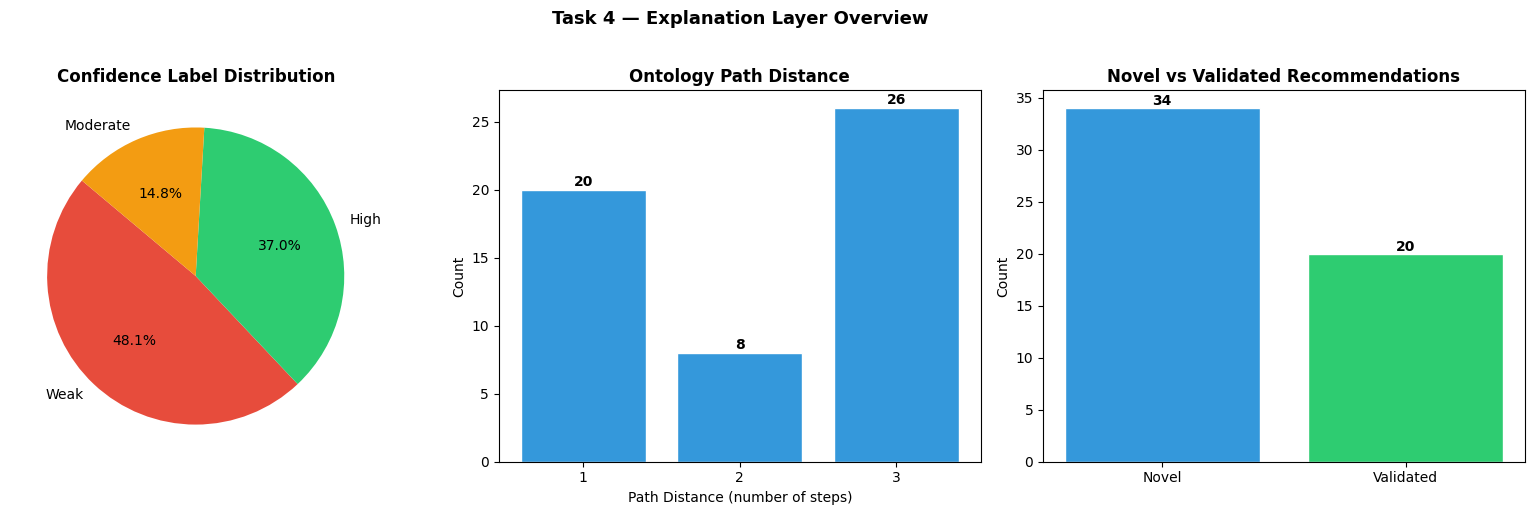

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confidence label pie chart
lc = df_out['confidence_label'].value_counts()
color_map = {'High': '#2ecc71', 'Moderate': '#f39c12', 'Weak': '#e74c3c'}
axes[0].pie(lc.values, labels=lc.index,
            colors=[color_map.get(l, '#aaa') for l in lc.index],
            autopct='%1.1f%%', startangle=140)
axes[0].set_title('Confidence Label Distribution', fontweight='bold')

# Path distance bar chart
dc = df_out['path_distance'].value_counts().sort_index()
axes[1].bar(dc.index.astype(str), dc.values, color='#3498db', edgecolor='white')
axes[1].set_xlabel('Path Distance (number of steps)')
axes[1].set_ylabel('Count')
axes[1].set_title('Ontology Path Distance', fontweight='bold')
for i, (k, v) in enumerate(dc.items()):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontsize=10, fontweight='bold')

# Known vs novel bar chart
nc = df_out['known_positive'].value_counts()
axes[2].bar(['Novel', 'Validated'],
            [nc.get(False, 0), nc.get(True, 0)],
            color=['#3498db', '#2ecc71'], edgecolor='white')
axes[2].set_ylabel('Count')
axes[2].set_title('Novel vs Validated Recommendations', fontweight='bold')
for i, v in enumerate([nc.get(False, 0), nc.get(True, 0)]):
    axes[2].text(i, v + 0.3, str(v), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Task 4 — Explanation Layer Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task4_overview.png', dpi=150, bbox_inches='tight')
plt.show()

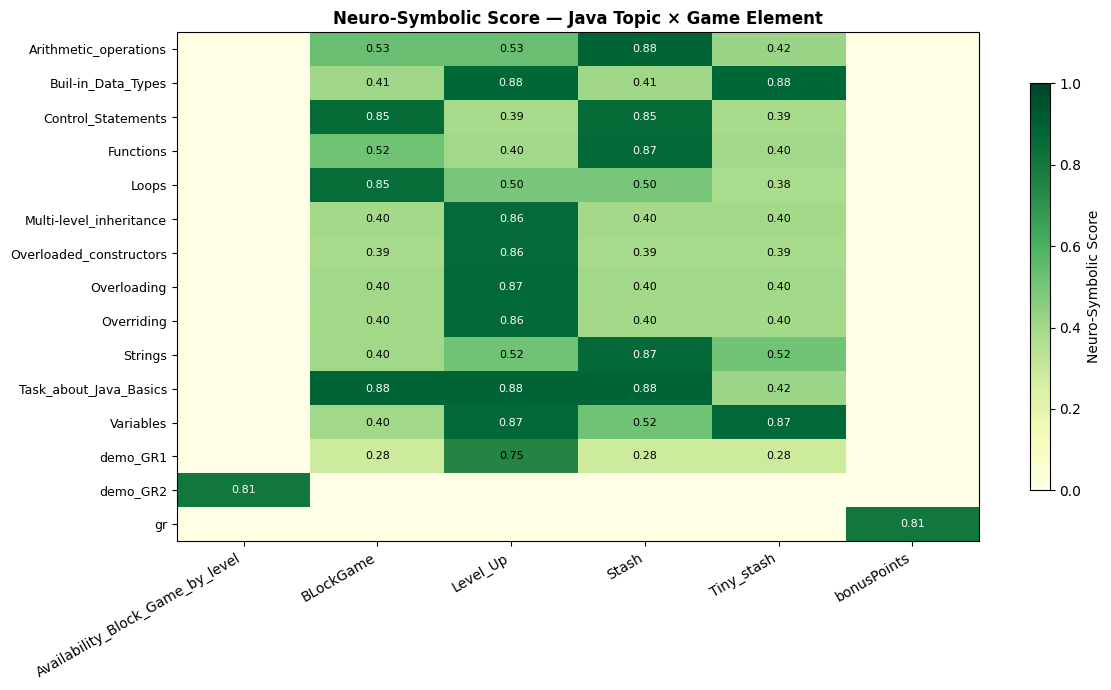

In [14]:
# Score distribution per Java topic (heatmap)
pivot = df_out.pivot_table(
    index='source', columns='target',
    values='neurosymbolic_score', aggfunc='max'
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlGn', vmin=0, vmax=1)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if val < 0.75 else 'white')

plt.colorbar(im, ax=ax, shrink=0.8, label='Neuro-Symbolic Score')
ax.set_title('Neuro-Symbolic Score — Java Topic × Game Element', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('task4_score_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Output

In [15]:
output_cols = [
    'source', 'target',
    'probability_mean', 'symbolic_confidence', 'neurosymbolic_score',
    'confidence_label', 'path_distance', 'key_relation',
    'ontology_path', 'known_positive', 'explanation'
]

df_out[output_cols].to_csv('task4_explanations.csv', index=False)

print('Saved: task4_explanations.csv')
print(f'Rows    : {len(df_out)}')
print(f'Columns : {output_cols}')

Saved: task4_explanations.csv
Rows    : 54
Columns : ['source', 'target', 'probability_mean', 'symbolic_confidence', 'neurosymbolic_score', 'confidence_label', 'path_distance', 'key_relation', 'ontology_path', 'known_positive', 'explanation']


# Download outputs and artifacts

In [ ]:
import os, zipfile
from google.colab import files

EXCLUDE = {'.config', 'sample_data', '__pycache__', '.ipynb_checkpoints'}

def _should_skip(path):
    return any(part in EXCLUDE for part in path.split(os.sep))

with zipfile.ZipFile('outputs.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    for root, dirs, filenames in os.walk('.'):
        dirs[:] = [d for d in dirs if d not in EXCLUDE]
        for f in filenames:
            if f == 'outputs.zip':
                continue
            full = os.path.join(root, f)
            if not _should_skip(full):
                z.write(full)

print(f'outputs.zip créé ({os.path.getsize("outputs.zip") / 1024**2:.1f} MB)')

# Then download output.zip with all artifacts useful for mlops and interface

outputs.zip créé (1.0 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Report Text

> **Task 4 — Explanation Generation (Layer 5)**
>
> Layer 5 implements the explainability module of the neuro-symbolic pipeline.
> For each recommendation produced by Task 3, the system reconstructs the shortest
> ontological path between the Java topic and the recommended game element using the
> knowledge graph built in Task 1. The path is extracted with its full semantics:
> not only the sequence of nodes but also the relation type of each edge
> (e.g. `containsGameElement`, `hasPreResource`, `indexed_by`), producing
> interpretable chains such as
> `Arithmetic_operations --hasPreResource--> Task_about_Java_Basics --containsGameElement--> BLockGame`.
>
> The explanation is then generated from four independent blocks: (1) a strength
> statement based on the neuro-symbolic score and validation status, (2) an
> ontological support statement based on the symbolic confidence and path distance,
> (3) the explicit ontological path with relation types, and (4) a pedagogical
> description of the recommended game element. This modular architecture allows
> new dimensions to be added in future iterations — such as teacher experience
> level or learning objectives — without modifying existing logic.
>
> The output is a structured CSV containing, for each of the 55 recommendations,
> the full explanation alongside the path distance, key relation type, confidence
> label, and novelty status, making the system's reasoning fully transparent
> and auditable by teachers.